# BPY518 Lecture 5: Particle Tracking
Instructor: Josh Shaevitz  
Email: shaevitz@princeton.edu

## Lecture Outline
- Spot detection and the particle-tracking pipeline
- LoG filtering and local peak finding
- Subpixel localization by centroid and Gaussian fitting
- Linking particles across frames
- Nearest-neighbor and Hungarian assignment
- When to use richer temporal models or optical flow

Particle tracking is a standard workflow in microscopy when objects appear as isolated bright spots: single molecules, small fluorescent complexes, FISH puncta, or diffraction-limited particles.

The source deck starts with a typical sparse fluorescence field:

![Typical fluorescence field](media/particle_field.png)

The high-level pipeline is:

1. Preprocess the image.
2. Find candidate peaks at pixel resolution.
3. Refine positions to subpixel accuracy.
4. Link detections across time.

This notebook follows that same structure with runnable examples.

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, spatial
from scipy.optimize import curve_fit, linear_sum_assignment

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

media_dir = Path('media')
rng = np.random.default_rng(7)

## A Single Particle Looks Like a Local Intensity Peak

A diffraction-limited emitter does not look like a single bright pixel. Its light is spread out by the microscope point-spread function (PSF), so each particle appears as a small blurry mound of intensity.

The slide deck illustrates that shape with a 3D surface plot:

![3D surface of a single particle](media/single_molecule_surface.png)

That is why particle localization is usually phrased as an estimation problem: given a noisy mound of intensity, where is the center?

In [2]:
def make_spot_image(shape, positions, amplitudes=None, sigma=1.8, background=20.0, noise=3.0, rng=None):
    yy, xx = np.mgrid[: shape[0], : shape[1]]
    image = np.full(shape, background, dtype=float)
    if amplitudes is None:
        amplitudes = np.full(len(positions), 180.0)
    for (y0, x0), amp in zip(positions, amplitudes):
        image += amp * np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * sigma**2))
    if rng is not None:
        image += noise * rng.normal(size=shape)
    return np.clip(image, 0, None)


def find_local_maxima(image, min_distance=4, threshold=0.0):
    size = 2 * min_distance + 1
    local_max = ndimage.maximum_filter(image, size=size, mode='reflect')
    peaks = np.argwhere((image == local_max) & (image > threshold))
    return peaks


def centroid_localization(image, y, x, radius=4):
    y_min = max(0, y - radius)
    y_max = min(image.shape[0], y + radius + 1)
    x_min = max(0, x - radius)
    x_max = min(image.shape[1], x + radius + 1)
    window = image[y_min:y_max, x_min:x_max]
    weights = window - np.min(window)
    total_intensity = np.sum(weights)
    if total_intensity <= 0:
        return np.array([float(y), float(x)])
    yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
    y_centroid = np.sum(yy * weights) / total_intensity
    x_centroid = np.sum(xx * weights) / total_intensity
    return np.array([y_centroid, x_centroid])


def gaussian_2d(coords, A, x0, y0, sigma, B):
    x, y = coords
    return A * np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma**2)) + B


def fit_gaussian_2d(image, y, x, radius=5):
    y_min = max(0, y - radius)
    y_max = min(image.shape[0], y + radius + 1)
    x_min = max(0, x - radius)
    x_max = min(image.shape[1], x + radius + 1)
    patch = image[y_min:y_max, x_min:x_max]
    yy, xx = np.mgrid[y_min:y_max, x_min:x_max]
    baseline = float(np.median(patch))
    amplitude = float(np.max(patch) - baseline)
    p0 = (amplitude, float(x), float(y), 2.0, baseline)
    bounds = (
        [0.0, x_min, y_min, 0.5, 0.0],
        [np.inf, x_max, y_max, 6.0, np.inf],
    )
    popt, _ = curve_fit(
        gaussian_2d,
        (xx.ravel(), yy.ravel()),
        patch.ravel(),
        p0=p0,
        bounds=bounds,
        maxfev=2000,
    )
    return {
        'amplitude': popt[0],
        'x': popt[1],
        'y': popt[2],
        'sigma': popt[3],
        'background': popt[4],
        'patch': patch,
        'xx': xx,
        'yy': yy,
    }


def compute_cost_matrix(points_t, points_t1):
    return np.linalg.norm(points_t[:, None, :] - points_t1[None, :, :], axis=2)

## Preprocessing and LoG Filtering

The slide deck lists several reasonable preprocessing options, including Gaussian smoothing, bandpass filtering, median filtering, and the **Laplacian of Gaussian (LoG)**. For spot detection, LoG filtering is a common choice because it emphasizes small blob-like features while suppressing smooth background structure.

We will demonstrate it on a synthetic image of fluorescent spots.

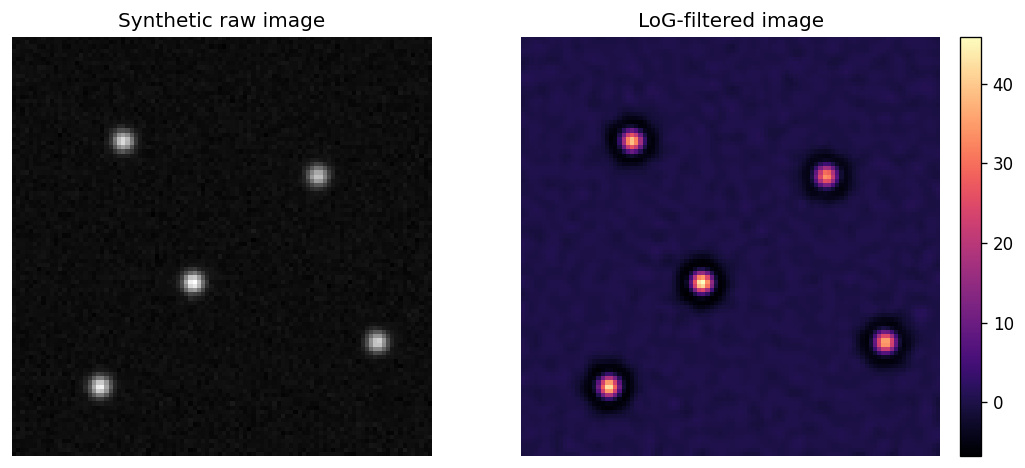

In [3]:
# Create a synthetic field of fluorescent spots and filter it with a LoG kernel.
demo_positions = np.array([
    [24.5, 26.0],
    [32.8, 72.4],
    [58.2, 42.7],
    [72.4, 86.5],
    [83.0, 20.5],
])
demo_amplitudes = np.array([210, 180, 240, 195, 225], dtype=float)
demo_image = make_spot_image((100, 100), demo_positions, amplitudes=demo_amplitudes, sigma=1.7, background=18, noise=3.5, rng=rng)
log_filtered = -ndimage.gaussian_laplace(demo_image, sigma=1.6)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(demo_image)
axes[0].set_title('Synthetic raw image')
axes[0].axis('off')

im = axes[1].imshow(log_filtered, cmap='magma')
axes[1].set_title('LoG-filtered image')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()

## Local Peak Finding with a Maximum Filter

After filtering, we still need to decide which pixels are candidate particles. The deck describes a standard rule:

- a peak must be brighter than its neighbors in a local window,
- and it must exceed a threshold.

A maximum filter makes that easy: every pixel is replaced by the maximum value in its neighborhood. Pixels that are unchanged by this operation and also exceed the threshold are local maxima.

Detected peaks (row, col):
[[25 26]
 [33 72]
 [58 43]
 [72 86]
 [83 21]]


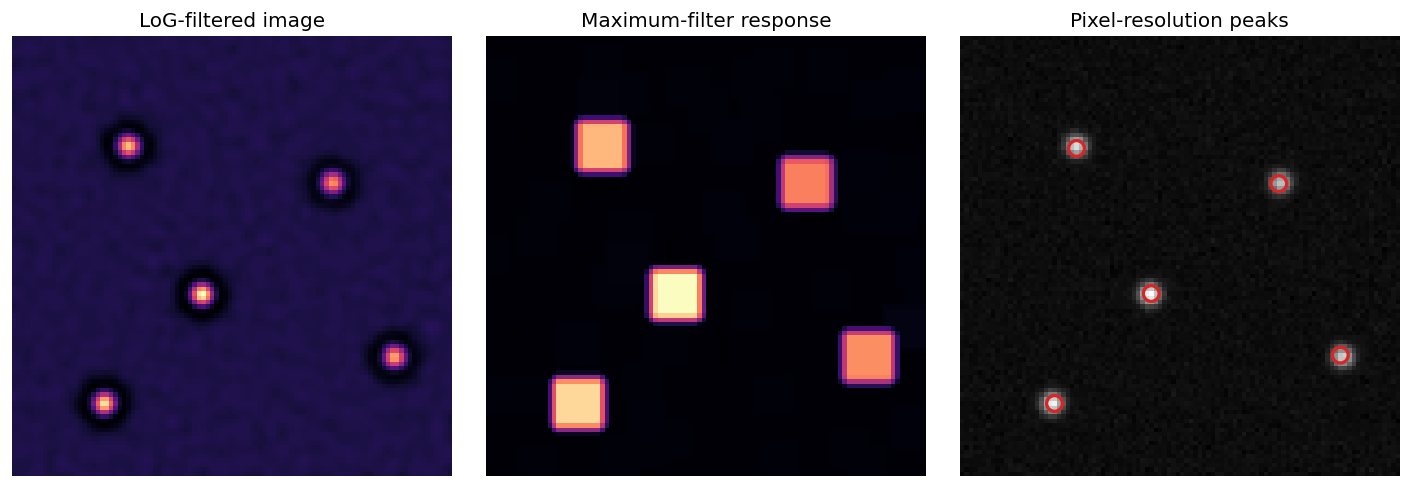

In [4]:
# Detect candidate peaks at pixel resolution.
peak_threshold = log_filtered.mean() + 2.8 * log_filtered.std()
max_filtered = ndimage.maximum_filter(log_filtered, size=9, mode='reflect')
peaks = find_local_maxima(log_filtered, min_distance=4, threshold=peak_threshold)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(log_filtered, cmap='magma')
axes[0].set_title('LoG-filtered image')
axes[0].axis('off')

axes[1].imshow(max_filtered, cmap='magma')
axes[1].set_title('Maximum-filter response')
axes[1].axis('off')

axes[2].imshow(demo_image)
axes[2].scatter(peaks[:, 1], peaks[:, 0], s=90, facecolors='none', edgecolors='C3', linewidths=2)
axes[2].set_title('Pixel-resolution peaks')
axes[2].axis('off')

plt.tight_layout()
print('Detected peaks (row, col):')
print(peaks)

## Subpixel Localization by Centroid

The centroid method computes an intensity-weighted average of nearby pixel coordinates:

$$
x_c = \frac{\sum x I(x, y)}{\sum I(x, y)}, \qquad y_c = \frac{\sum y I(x, y)}{\sum I(x, y)}.
$$

It is simple and fast, and often gives a noticeable improvement over using the single brightest pixel.

The source deck compares centroiding to the peak pixel directly:

![Centroid versus peak pixel](media/centroid_vs_peak.png)

Peak pixel: (58, 43)
Centroid  : (58.18, 42.77)


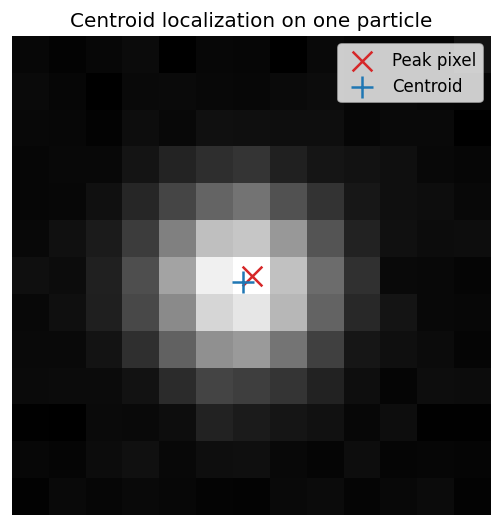

In [5]:
# Compare the peak pixel and the centroid estimate for one detected particle.
peak_values = log_filtered[peaks[:, 0], peaks[:, 1]]
peak_y, peak_x = peaks[np.argmax(peak_values)]
centroid_y, centroid_x = centroid_localization(demo_image, int(peak_y), int(peak_x), radius=5)

radius = 6
y_min = max(0, int(peak_y) - radius)
y_max = min(demo_image.shape[0], int(peak_y) + radius + 1)
x_min = max(0, int(peak_x) - radius)
x_max = min(demo_image.shape[1], int(peak_x) + radius + 1)
patch = demo_image[y_min:y_max, x_min:x_max]

plt.figure(figsize=(4.5, 4.5))
plt.imshow(patch)
plt.scatter(peak_x - x_min, peak_y - y_min, marker='x', s=140, color='C3', label='Peak pixel')
plt.scatter(centroid_x - x_min, centroid_y - y_min, marker='+', s=160, color='C0', label='Centroid')
plt.legend(loc='upper right')
plt.title('Centroid localization on one particle')
plt.axis('off')
plt.tight_layout()

print(f'Peak pixel: ({peak_y}, {peak_x})')
print(f'Centroid  : ({centroid_y:.2f}, {centroid_x:.2f})')

## Subpixel Localization by Gaussian Fitting

A more model-based approach is to fit the particle image to a 2D Gaussian. This is usually more accurate than centroiding when the signal-to-noise ratio is good, because the fit uses the whole local intensity profile rather than only a weighted average.

The source deck contrasts Gaussian fitting with the peak pixel estimate:

![Gaussian fit versus peak pixel](media/gaussian_fit_vs_peak.png)

This is exactly the same `curve_fit` logic students have already seen earlier in the course, now applied to a 2D image patch instead of a 1D curve.

Gaussian fit center: (58.22, 42.70)
Estimated sigma   : 1.68 pixels


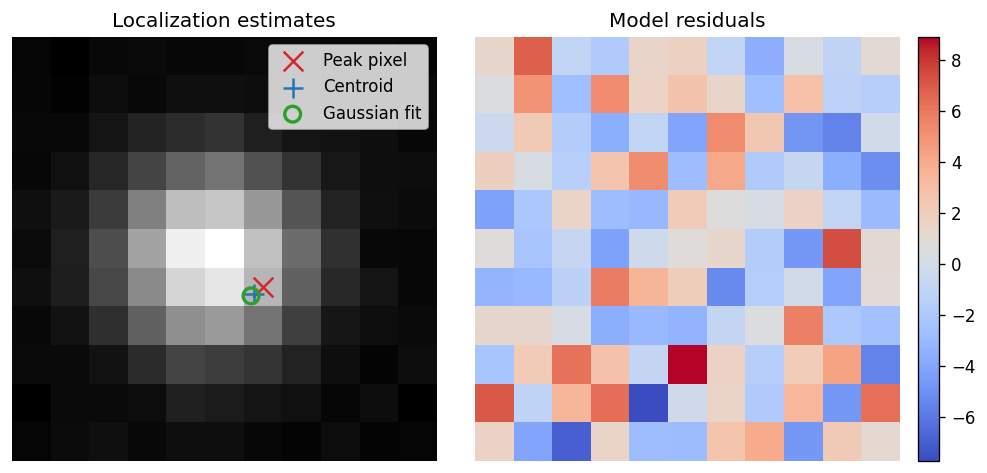

In [6]:
# Fit the same particle with a 2D Gaussian model.
fit_result = fit_gaussian_2d(demo_image, int(peak_y), int(peak_x), radius=5)
fit_y = fit_result['y']
fit_x = fit_result['x']
model_patch = gaussian_2d(
    (fit_result['xx'], fit_result['yy']),
    fit_result['amplitude'],
    fit_result['x'],
    fit_result['y'],
    fit_result['sigma'],
    fit_result['background'],
)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
axes[0].imshow(fit_result['patch'])
axes[0].scatter(peak_x - x_min, peak_y - y_min, marker='x', s=140, color='C3', label='Peak pixel')
axes[0].scatter(centroid_x - x_min, centroid_y - y_min, marker='+', s=150, color='C0', label='Centroid')
axes[0].scatter(fit_x - x_min, fit_y - y_min, marker='o', s=90, facecolors='none', edgecolors='C2', linewidths=2, label='Gaussian fit')
axes[0].set_title('Localization estimates')
axes[0].axis('off')
axes[0].legend(loc='upper right')

im = axes[1].imshow(model_patch - fit_result['patch'], cmap='coolwarm')
axes[1].set_title('Model residuals')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()

print(f'Gaussian fit center: ({fit_y:.2f}, {fit_x:.2f})')
print(f'Estimated sigma   : {fit_result["sigma"]:.2f} pixels')

## Tracking Over Time

Once we have positions in each frame, the next step is to match detections between successive frames. The slide deck frames this as a data-association problem: which particle in frame `t+1` is the continuation of each particle in frame `t`?

We will simulate a short movie of moving particles and localize them frame by frame.

Localized particles per frame: [4, 4, 4, 4, 4, 4]


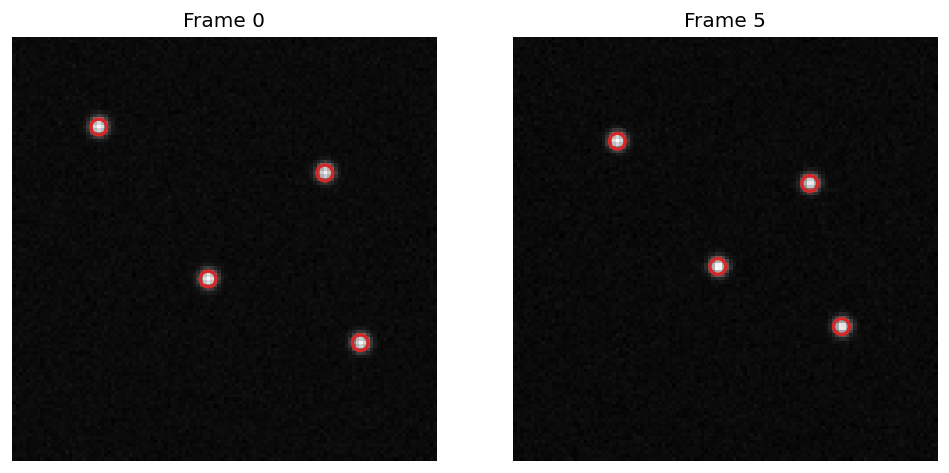

In [7]:
# Build a short synthetic movie and localize particles in each frame.
movie_shape = (120, 120)
start_positions = np.array([
    [25.0, 24.0],
    [38.0, 88.0],
    [68.0, 55.0],
    [86.0, 98.0],
], dtype=float)
velocities = np.array([
    [0.8, 1.0],
    [0.6, -0.9],
    [-0.7, 0.5],
    [-0.9, -1.1],
], dtype=float)

movie_frames = []
localized_positions = []
for t in range(6):
    positions_t = start_positions + t * velocities
    frame_rng = np.random.default_rng(100 + t)
    frame = make_spot_image(movie_shape, positions_t, amplitudes=[220, 210, 230, 215], sigma=1.7, background=14, noise=2.5, rng=frame_rng)
    response = -ndimage.gaussian_laplace(frame, sigma=1.5)
    threshold = response.mean() + 2.8 * response.std()
    peaks_t = find_local_maxima(response, min_distance=4, threshold=threshold)
    refined_t = np.array([centroid_localization(frame, int(y), int(x), radius=4) for y, x in peaks_t])
    movie_frames.append(frame)
    localized_positions.append(refined_t)

fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
for ax, frame_idx in zip(axes, [0, 5]):
    ax.imshow(movie_frames[frame_idx])
    pts = localized_positions[frame_idx]
    ax.scatter(pts[:, 1], pts[:, 0], s=90, facecolors='none', edgecolors='C3', linewidths=2)
    ax.set_title(f'Frame {frame_idx}')
    ax.axis('off')
plt.tight_layout()

print('Localized particles per frame:', [len(p) for p in localized_positions])

## Nearest-Neighbor Matching

The simplest linker is greedy nearest-neighbor matching: for each particle in frame `t`, find the closest particle in frame `t+1` within a maximum displacement threshold.

This works well when motion is small and particles are sparse. The deck also notes that a `cKDTree` lookup can make this much faster.

Particle 0 -> 0, distance = 1.26
Particle 1 -> 1, distance = 1.12
Particle 2 -> 2, distance = 0.87
Particle 3 -> 3, distance = 1.45


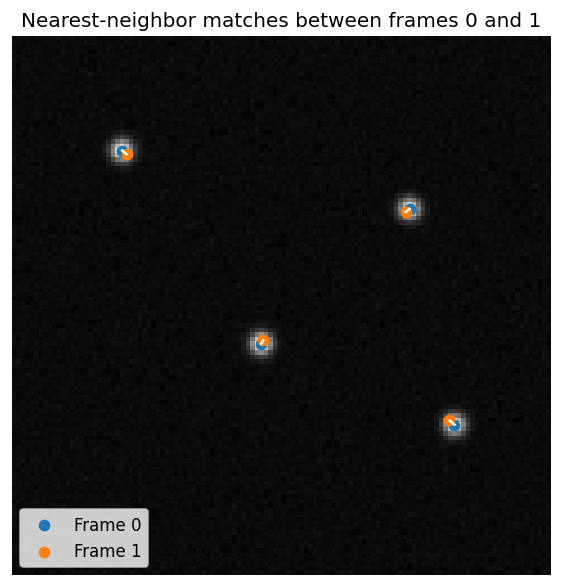

In [8]:
# Match two successive frames with a nearest-neighbor search.
points_t = localized_positions[0]
points_t1 = localized_positions[1]
max_distance = 5.0

tree = spatial.cKDTree(points_t1)
distances, indices = tree.query(points_t, distance_upper_bound=max_distance)
valid = np.isfinite(distances)

plt.figure(figsize=(5, 5))
plt.imshow(movie_frames[0])
plt.scatter(points_t[:, 1], points_t[:, 0], color='C0', label='Frame 0')
plt.scatter(points_t1[:, 1], points_t1[:, 0], color='C1', label='Frame 1')
for i, (dist, j) in enumerate(zip(distances, indices)):
    if np.isfinite(dist) and j < len(points_t1):
        plt.plot([points_t[i, 1], points_t1[j, 1]], [points_t[i, 0], points_t1[j, 0]], color='white', linewidth=1.5)
plt.legend(loc='lower left')
plt.title('Nearest-neighbor matches between frames 0 and 1')
plt.axis('off')
plt.tight_layout()

for i, (dist, j) in enumerate(zip(distances, indices)):
    if np.isfinite(dist) and j < len(points_t1):
        print(f'Particle {i} -> {j}, distance = {dist:.2f}')

## Global Assignment with the Hungarian Algorithm

Nearest-neighbor matching can fail when particles get close together. A better strategy is to build a full cost matrix of pairwise distances and find the one-to-one assignment that minimizes the **total** cost.

The source deck summarizes that idea visually:

![Hungarian assignment](media/hungarian_assignment.png)

In Python, `scipy.optimize.linear_sum_assignment` solves this optimal assignment problem.

Assignments (frame 0 index -> frame 1 index): [(0, 0), (1, 1), (2, 2), (3, 3)]


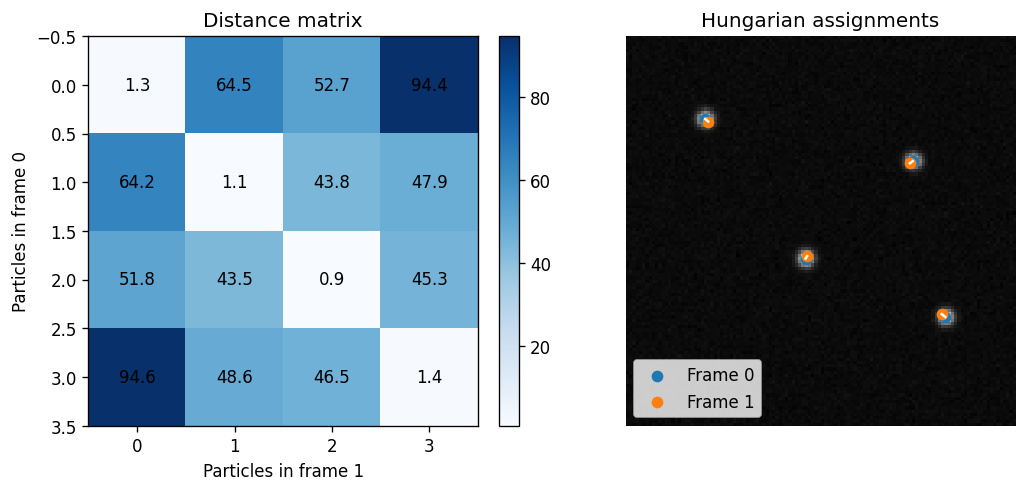

In [9]:
# Solve the same frame-to-frame association problem globally.
cost_matrix = compute_cost_matrix(points_t, points_t1)
row_ind, col_ind = linear_sum_assignment(cost_matrix)
accepted = cost_matrix[row_ind, col_ind] <= max_distance
assignments = [(int(i), int(j)) for i, j in zip(row_ind[accepted], col_ind[accepted])]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
im = axes[0].imshow(cost_matrix, cmap='Blues')
axes[0].set_title('Distance matrix')
axes[0].set_xlabel('Particles in frame 1')
axes[0].set_ylabel('Particles in frame 0')
for i in range(cost_matrix.shape[0]):
    for j in range(cost_matrix.shape[1]):
        axes[0].text(j, i, f'{cost_matrix[i, j]:.1f}', ha='center', va='center', color='black')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].imshow(movie_frames[0])
axes[1].scatter(points_t[:, 1], points_t[:, 0], color='C0', label='Frame 0')
axes[1].scatter(points_t1[:, 1], points_t1[:, 0], color='C1', label='Frame 1')
for i, j in assignments:
    axes[1].plot([points_t[i, 1], points_t1[j, 1]], [points_t[i, 0], points_t1[j, 0]], color='white', linewidth=1.5)
axes[1].set_title('Hungarian assignments')
axes[1].axis('off')
axes[1].legend(loc='lower left')
plt.tight_layout()

print('Assignments (frame 0 index -> frame 1 index):', assignments)

Track lengths: {0: 6, 1: 6, 2: 6, 3: 6}


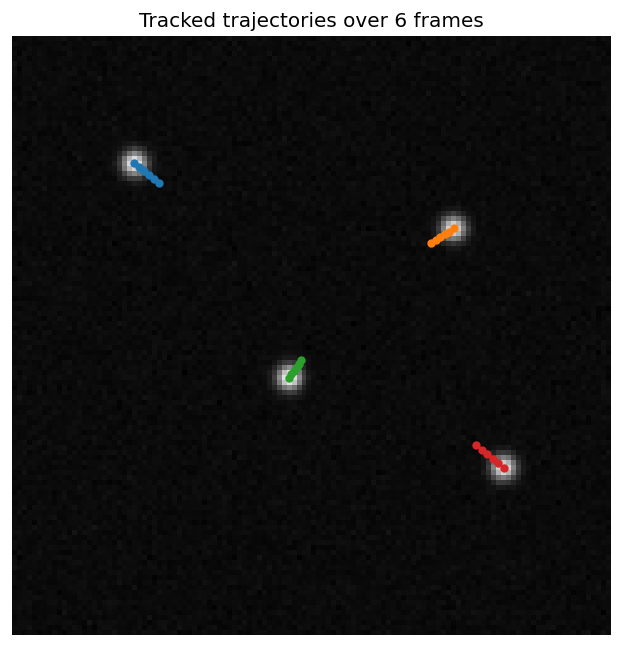

In [10]:
# Extend Hungarian matching across the whole movie to build simple tracks.
tracks = {track_id: [point] for track_id, point in enumerate(localized_positions[0])}
prev_points = localized_positions[0]
prev_ids = np.arange(len(prev_points))
next_track_id = len(prev_points)

for frame_idx in range(1, len(localized_positions)):
    current_points = localized_positions[frame_idx]
    cost = compute_cost_matrix(prev_points, current_points)
    row_ind, col_ind = linear_sum_assignment(cost)

    new_ids = np.full(len(current_points), -1, dtype=int)
    for r, c in zip(row_ind, col_ind):
        if cost[r, c] <= max_distance:
            track_id = prev_ids[r]
            tracks[track_id].append(current_points[c])
            new_ids[c] = track_id

    for c in range(len(current_points)):
        if new_ids[c] == -1:
            tracks[next_track_id] = [current_points[c]]
            new_ids[c] = next_track_id
            next_track_id += 1

    prev_points = current_points
    prev_ids = new_ids

plt.figure(figsize=(5.5, 5.5))
plt.imshow(movie_frames[0])
for track_id, pts in tracks.items():
    pts = np.array(pts)
    plt.plot(pts[:, 1], pts[:, 0], '-o', linewidth=1.5, markersize=4, label=f'Track {track_id}')
plt.title('Tracked trajectories over 6 frames')
plt.axis('off')
plt.tight_layout()

print('Track lengths:', {track_id: len(points) for track_id, points in tracks.items()})

## Beyond Simple Frame-to-Frame Linking

The slide deck ends with two important points:

- **Temporal models** such as Kalman filters can help when particles cross, disappear briefly, or move in a predictable way.
- **TrackPy** is a full particle-tracking toolkit that packages many of these ideas into a practical workflow.
- If the signal is not naturally sparse and point-like, **optical flow** or **particle image velocimetry (PIV)** may be a better representation of motion than explicit particle linking.

So the right method depends on the biology and on the image formation: sparse spots suggest particle tracking, while dense continuous motion fields suggest flow methods.

## Key Points

- Particle tracking is usually a four-stage workflow: preprocess, detect, localize, then link.
- LoG filtering and local maxima provide a simple spot-detection pipeline.
- Centroiding is fast; Gaussian fitting is usually more accurate when the PSF is well behaved.
- Linking detections over time is a matching problem, not just a detection problem.
- Nearest-neighbor methods are simple, while Hungarian assignment resolves global conflicts more reliably.
- Richer temporal models and optical-flow methods become useful when the data are crowded or continuous.